In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


In [2]:
TRAIN_DIR = r"D:/DR_severity_project/dataset/raw/patient_split/train"
VAL_DIR   = r"D:/DR_severity_project/dataset/raw/patient_split/val"

IMG_SIZE = 224
BATCH_SIZE = 16


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


Found 28100 files belonging to 2 classes.
Found 7026 files belonging to 2 classes.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)


In [5]:
y_train = []

for _, labels in train_ds:
    y_train.extend(labels.numpy().flatten())

y_train = np.array(y_train).astype(int)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Class weights:", class_weights)


Class weights: {0: 0.6790063792770152, 1: 1.8965982721382288}


In [6]:
def binary_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow((1 - p_t), gamma)
        return tf.reduce_mean(alpha_factor * modulating_factor * bce)
    return loss


In [9]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # Phase 1

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=binary_focal_loss(),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [ ]:
checkpoint = ModelCheckpoint(
    "best_phase1.weights.h5",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks = [
    checkpoint,
    EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6)
]


In [13]:
model.load_weights("best_phase1.weights.h5")
print("Phase 1 best weights loaded.")


Phase 1 best weights loaded.


In [14]:
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=binary_focal_loss(),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [15]:
checkpoint2 = ModelCheckpoint(
    "best_phase2.weights.h5",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint2]
)


Epoch 1/20
879/879 [==============================] - ETA: 0s - loss: 0.0381 - accuracy: 0.7584 - auc: 0.6782
Epoch 1: val_auc improved from -inf to 0.74445, saving model to best_phase2.weights.h5
879/879 [==============================] - 718s 798ms/step - loss: 0.0381 - accuracy: 0.7584 - auc: 0.6782 - val_loss: 0.1024 - val_accuracy: 0.7559 - val_auc: 0.7444
Epoch 2/20
879/879 [==============================] - ETA: 0s - loss: 0.0356 - accuracy: 0.7668 - auc: 0.7053
Epoch 2: val_auc improved from 0.74445 to 0.74963, saving model to best_phase2.weights.h5
879/879 [==============================] - 709s 803ms/step - loss: 0.0356 - accuracy: 0.7668 - auc: 0.7053 - val_loss: 0.1048 - val_accuracy: 0.7615 - val_auc: 0.7496
Epoch 3/20
879/879 [==============================] - ETA: 0s - loss: 0.0339 - accuracy: 0.7738 - auc: 0.7160
Epoch 3: val_auc improved from 0.74963 to 0.75296, saving model to best_phase2.weights.h5
879/879 [==============================] - 695s 788ms/step - loss: 0.

In [16]:
model.load_weights("best_phase2.weights.h5")
print("Final best weights loaded.")


Final best weights loaded.


In [19]:
import numpy as np
from sklearn.metrics import accuracy_score

# Get probabilities
y_true = []
y_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds.flatten())
    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

print("Collected predictions.")


Collected predictions.


In [20]:
best_acc = 0
best_thresh = 0

for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_probs >= t).astype(int)
    acc = accuracy_score(y_true, y_pred)

    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best Accuracy:", best_acc)


Best Threshold: 0.13999999999999999
Best Accuracy: 0.8035866780529461


In [21]:
final_preds = (y_probs >= best_thresh).astype(int)
final_acc = accuracy_score(y_true, final_preds)

print("FINAL VALIDATION ACCURACY:", final_acc)


FINAL VALIDATION ACCURACY: 0.8035866780529461


In [22]:
model.save_weights("final_binary_dr_weights.weights.h5")
print("Weights saved successfully.")


Weights saved successfully.


In [23]:
best_thresh = 0.14


In [25]:
from sklearn.metrics import classification_report
report = classification_report(y_true, final_preds)

with open("final_validation_report.txt", "w") as f:
    f.write(report)

print("Report saved.")


Report saved.


In [16]:
IMG_SIZE = 224
BATCH_SIZE = 16


In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


Found 28100 files belonging to 2 classes.
Found 7026 files belonging to 2 classes.


In [8]:
import tensorflow as tf
tf.keras.backend.clear_session()


In [9]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Laptop GPU, compute capability 8.6


In [10]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
import tensorflow as tf

def build_model():
    base_model = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = True  # FULL fine-tuning

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_input(inputs)
    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)


    model = models.Model(inputs, outputs)
    return model


In [12]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-6,
    decay_steps=10000
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

NEW_WEIGHTS_PATH = "best_binary_dr_v2.weights.h5"

checkpoint = ModelCheckpoint(
    NEW_WEIGHTS_PATH,
    monitor="val_accuracy",     # now optimize accuracy
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

print("Callbacks ready. New weights will be saved as:", NEW_WEIGHTS_PATH)


Callbacks ready. New weights will be saved as: best_binary_dr_v2.weights.h5


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/30
1757/1757 [==============================] - ETA: 0s - loss: 0.0703 - accuracy: 0.7082 - auc: 0.6152
Epoch 1: val_accuracy improved from 0.52078 to 0.72801, saving model to best_binary_dr_v2.weights.h5
1757/1757 [==============================] - 385s 211ms/step - loss: 0.0703 - accuracy: 0.7082 - auc: 0.6152 - val_loss: 0.1154 - val_accuracy: 0.7280 - val_auc: 0.4840 - lr: 1.0000e-04
Epoch 2/30
1757/1757 [==============================] - ETA: 0s - loss: 0.0394 - accuracy: 0.7754 - auc: 0.7100
Epoch 2: val_accuracy improved from 0.72801 to 0.73114, saving model to best_binary_dr_v2.weights.h5
1757/1757 [==============================] - 383s 217ms/step - loss: 0.0394 - accuracy: 0.7754 - auc: 0.7100 - val_loss: 0.1055 - val_accuracy: 0.7311 - val_auc: 0.4846 - lr: 1.0000e-04
Epoch 3/30
1757/1757 [==============================] - ETA: 0s - loss: 0.0327 - accuracy: 0.7923 - auc: 0.7528
Epoch 3: val_accuracy did not improve from 0.73114
1757/1757 [============================

In [20]:
from sklearn.metrics import accuracy_score
import numpy as np

y_probs = model.predict(val_ds).ravel()

best_acc = 0
best_thresh = 0

for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_probs >= t).astype(int)
    acc = accuracy_score(y_true, y_pred)

    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best Accuracy:", best_acc)


440/440 [==============================] - 35s 80ms/step
Best Threshold: 0.5999999999999998
Best Accuracy: 0.7395388556789069


In [21]:
IMG_SIZE = 300
BATCH_SIZE = 8   # reduce from whatever you had (likely 16/32)


In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 28100 files belonging to 2 classes.
Found 7026 files belonging to 2 classes.


In [9]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # Phase 1 freeze

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 300, 300, 3)]     0         
                                                                 
 efficientnetb3 (Functional)  (None, 10, 10, 1536)     10783535  
                                                                 
 global_average_pooling2d_4   (None, 1536)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 batch_normalization_4 (Batc  (None, 1536)             6144      
 hNormalization)                                                 
                                                                 
 dropout_4 (Dropout)         (None, 1536)              0         
                                                                 
 dense_4 (Dense)             (None, 1)                 1537

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(
        "best_binary_dr_300_phase1.weights.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]


In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/12
3513/3513 [==============================] - ETA: 0s - loss: 0.7759 - accuracy: 0.5969 - auc: 0.6338
Epoch 1: val_auc improved from -inf to 0.72782, saving model to best_binary_dr_300_phase1.weights.h5
3513/3513 [==============================] - 252s 70ms/step - loss: 0.7759 - accuracy: 0.5969 - auc: 0.6338 - val_loss: 0.6133 - val_accuracy: 0.6816 - val_auc: 0.7278 - lr: 0.0010
Epoch 2/12
3512/3513 [============================>.] - ETA: 0s - loss: 0.7238 - accuracy: 0.6101 - auc: 0.6499
Epoch 2: val_auc did not improve from 0.72782
3513/3513 [==============================] - 298s 85ms/step - loss: 0.7238 - accuracy: 0.6101 - auc: 0.6499 - val_loss: 0.6277 - val_accuracy: 0.6704 - val_auc: 0.7230 - lr: 0.0010
Epoch 3/12
3512/3513 [============================>.] - ETA: 0s - loss: 0.7145 - accuracy: 0.6129 - auc: 0.6521
Epoch 3: val_auc improved from 0.72782 to 0.72943, saving model to best_binary_dr_300_phase1.weights.h5
3513/3513 [==============================] - 298s 8

In [26]:
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_finetune = [
    ModelCheckpoint(
        "best_binary_dr_300_finetune.weights.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)


Epoch 1/15
3513/3513 [==============================] - ETA: 0s - loss: 0.6175 - accuracy: 0.6733 - auc: 0.7245
Epoch 1: val_auc improved from -inf to 0.77018, saving model to best_binary_dr_300_finetune.weights.h5
3513/3513 [==============================] - 344s 94ms/step - loss: 0.6175 - accuracy: 0.6733 - auc: 0.7245 - val_loss: 0.5857 - val_accuracy: 0.7061 - val_auc: 0.7702 - lr: 1.0000e-05
Epoch 2/15
3513/3513 [==============================] - ETA: 0s - loss: 0.5968 - accuracy: 0.6903 - auc: 0.7513
Epoch 2: val_auc improved from 0.77018 to 0.77833, saving model to best_binary_dr_300_finetune.weights.h5
3513/3513 [==============================] - 341s 97ms/step - loss: 0.5968 - accuracy: 0.6903 - auc: 0.7513 - val_loss: 0.5602 - val_accuracy: 0.7348 - val_auc: 0.7783 - lr: 1.0000e-05
Epoch 3/15
3512/3513 [============================>.] - ETA: 0s - loss: 0.5807 - accuracy: 0.7045 - auc: 0.7709
Epoch 3: val_auc improved from 0.77833 to 0.78334, saving model to best_binary_dr_300

In [27]:
from sklearn.metrics import accuracy_score
import numpy as np

y_probs = model.predict(val_ds).ravel()

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy().flatten())
y_true = np.array(y_true)

best_acc = 0
best_thresh = 0

for t in np.arange(0.2, 0.8, 0.01):
    preds = (y_probs >= t).astype(int)
    acc = accuracy_score(y_true, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best Validation Accuracy:", best_acc)


879/879 [==============================] - 49s 54ms/step
Best Threshold: 0.7400000000000004
Best Validation Accuracy: 0.8095644748078565


In [28]:
import json

results = {
    "best_threshold": float(best_thresh),
    "best_validation_accuracy": float(best_acc)
}

with open("final_results_binary_dr_v2.json", "w") as f:
    json.dump(results, f, indent=4)

print("Results saved successfully.")


Results saved successfully.


In [29]:
model.save_weights("best_binary_dr_v2.weights.h5")
print("Weights saved successfully.")


Weights saved successfully.


In [31]:
import numpy as np

np.save("val_probs_v2.npy", y_probs)
np.save("val_labels_v2.npy", y_true)

print("Validation predictions saved.")


Validation predictions saved.


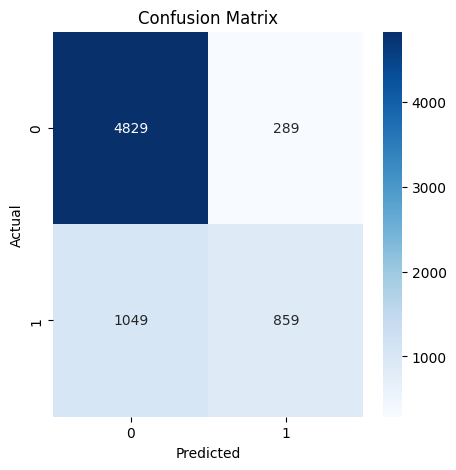

              precision    recall  f1-score   support

         0.0       0.82      0.94      0.88      5118
         1.0       0.75      0.45      0.56      1908

    accuracy                           0.81      7026
   macro avg       0.78      0.70      0.72      7026
weighted avg       0.80      0.81      0.79      7026



In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Final predictions using best threshold
final_preds = (y_probs >= best_thresh).astype(int)

cm = confusion_matrix(y_true, final_preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

report = classification_report(y_true, final_preds)
print(report)


In [33]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_v2.png")
plt.close()

print("Confusion matrix saved.")


Confusion matrix saved.


In [34]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve_v2.png")
plt.close()

print("ROC curve saved.")


ROC curve saved.


In [35]:
with open("final_results_binary_dr_v2.txt", "w") as f:
    f.write("FINAL BINARY DR RESULTS\n")
    f.write("------------------------\n")
    f.write(f"Best Threshold: {best_thresh}\n")
    f.write(f"Validation Accuracy: {best_acc}\n")
    f.write(f"ROC AUC: {roc_auc}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("Results saved to TXT file.")


Results saved to TXT file.


In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,8))

for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0).ravel()
batch_size = images.shape[0]

for i in range(min(9, batch_size)):

        ax = plt.subplot(3,3,i+1)

        img = images[i].numpy().astype("uint8")
        true_label = int(labels[i].numpy())
        pred_prob = preds[i]
        pred_label = int(pred_prob >= best_thresh)

        plt.imshow(img)
        plt.title(f"T:{true_label} P:{pred_label}\n{pred_prob:.2f}")
        plt.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions_v2.png")
plt.close()

print("Sample predictions saved.")


Sample predictions saved.
